# 05 — Final comparison + Phase 3 meta-ensemble

Pulls saved test metrics from every model we ship into one place,
shows the headline ranking and rating tables, and walks through the
Phase-3 LightGBM meta-ensemble.

**Variants**

- **SASRec** (A1, primary, `variants/hriday`): self-attentive sequential
  recommendation; uses the `date` column.
- **LightGCN-HG** (A2, secondary, `variants/hriday`): metadata-augmented
  graph convolution with TripAdvisor location pivots. Vanilla LightGCN
  (bipartite only) included as the day-10 vanilla-vs-enhanced baseline.
- **NeuMF-Attn** (B, `variants/aditya`): NeuMF backbone with optional
  per-user attention over six sub-rating aspects. Vanilla = attention off.
- **TextNCF** (C, `variants/pramod`): two-branch hybrid (collab + frozen
  MiniLM review embeddings). Vanilla = base hybrid; Multi-Task adds a
  rating-MSE head.

**Phase 3** — `LGBMRanker` (lambdarank) over per-user min-max normalised
scores from SASRec + LightGCN-HG + NeuMF-Attn + TextNCF-MT. Trained on
val (1-vs-99), evaluated on test, calibrated for RMSE the same way every
other model is.

All numbers below load from saved JSONs under `results/<variant>/`. No
re-training in this notebook.

In [1]:
import glob, json, re
from pathlib import Path

import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").is_dir() and (cand / "results").is_dir():
            return cand
    raise RuntimeError(f"no repo root from {start}")

REPO = find_repo_root(Path.cwd())
def load_json(p):
    p = Path(p)
    return json.loads(p.read_text()) if p.exists() else None

R = REPO / "results"
print("Repo:", REPO)


Repo: C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo


## 1. Headline ranking metrics (1-vs-99, test split)

One row per shipped model + ablation. Phase-1 baselines, Phase-2 variants
(both vanilla and enhanced where applicable), and the Phase-3 meta-
ensemble.

In [2]:
METRICS = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]

def row(d):
    return {m: float(d[m]) for m in METRICS if m in d}

rows = []
def add(label, d):
    if d is None: return
    rows.append({"model": label, **row(d)})

# Phase-1 baselines
b = load_json(R / "baselines" / "baseline_results_20core.json") or {}
for n in ("Popularity", "GMF", "ItemKNN"):
    if n in b: add(f"{n} (baseline)", b[n])

# Pramod's TextNCF family
add("Vanilla TextNCF (Pramod, base hybrid)",   load_json(R / "text_ncf"          / "test_metrics.json"))
add("TextNCF — GMF-only ablation (Pramod)",     load_json(R / "text_ncf_gmf_only" / "test_metrics.json"))
add("TextNCF — text-only ablation (Pramod)",    load_json(R / "text_ncf_text_only"/ "test_metrics.json"))
add("TextNCF Multi-Task (Pramod, enhanced)",    load_json(R / "text_ncf_mt"       / "test_metrics.json"))
add("TextNCF Sub-rating (Pramod)",              load_json(R / "text_ncf_subrating"/ "test_metrics.json"))

# Aditya's NeuMF
nv = load_json(R / "neumf_vanilla" / "test_metrics_gmf64_mlp64.json")
ne = load_json(R / "neumf_attn"    / "test_metrics_gmf64_mlp64.json")
add("Vanilla NeuMF (Aditya)",        nv)
add("NeuMF-Attn (Aditya, enhanced)", ne)

# Hriday's LightGCN family
hg_van = load_json(R / "lightgcn_hg" / "test_metrics_L1_d256_none.json")
hg_grc = load_json(R / "lightgcn_hg" / "test_metrics_L1_d256_grc.json")
sas    = load_json(R / "sasrec"      / "test_metrics_d128_L2.json")
add("Vanilla LightGCN (Hriday, bipartite)",        hg_van)
add("LightGCN-HG (Hriday secondary, +g/r/c)",      hg_grc)
add("SASRec (Hriday primary, dim=128, L=2)",       sas)

# Phase 3
phase3 = load_json(R / "phase3_meta" / "test_metrics.json")
add("Phase 3 — LGBMRanker meta-ensemble", phase3)

frame = pd.DataFrame(rows).set_index("model")
frame.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["NDCG@10"])


,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20
model,,,,,,
Popularity (baseline),0.3150,0.4215,0.5538,0.2318,0.2662,0.2995
GMF (baseline),0.5553,0.6685,0.7936,0.4498,0.4863,0.5179
ItemKNN (baseline),0.6835,0.6870,0.7091,0.6082,0.6093,0.6150
"Vanilla TextNCF (Pramod, base hybrid)",0.5688,0.6787,0.7951,0.4702,0.5057,0.5351
TextNCF — GMF-only ablation (Pramod),0.5585,0.6720,0.7930,0.4548,0.4915,0.5221
TextNCF — text-only ablation (Pramod),0.5659,0.6891,0.8183,0.4583,0.4981,0.5308
"TextNCF Multi-Task (Pramod, enhanced)",0.5742,0.6864,0.8031,0.4734,0.5097,0.5392
TextNCF Sub-rating (Pramod),0.5380,0.6677,0.8023,0.4291,0.4710,0.5050
Vanilla NeuMF (Aditya),0.5978,0.7254,0.8468,0.4815,0.5228,0.5536


## 2. HR@k and NDCG@k across models

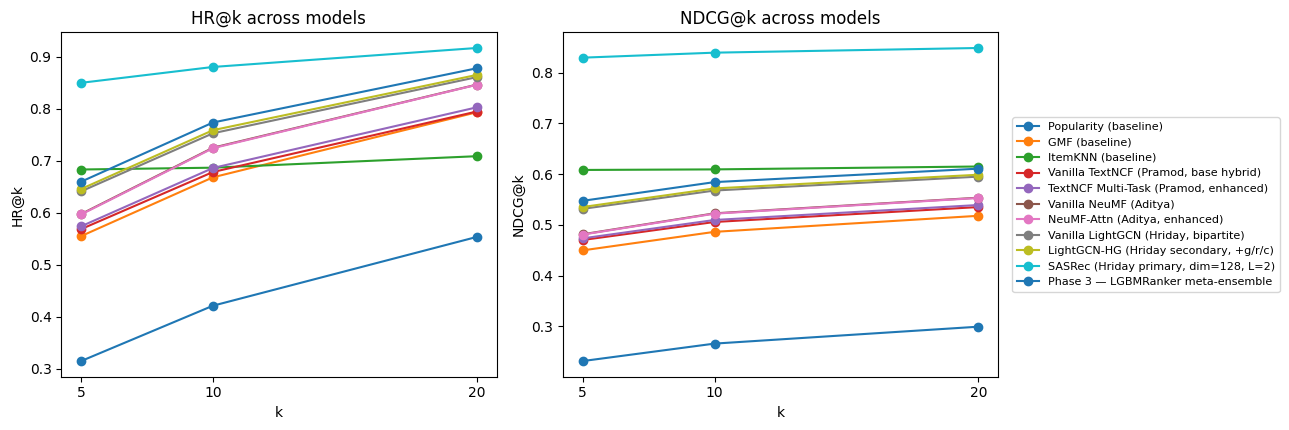

In [3]:
import matplotlib.pyplot as plt

# Pick a small set of headline models so the plot is readable.
HEADLINE = [
    "Popularity (baseline)",
    "GMF (baseline)",
    "ItemKNN (baseline)",
    "Vanilla TextNCF (Pramod, base hybrid)",
    "TextNCF Multi-Task (Pramod, enhanced)",
    "Vanilla NeuMF (Aditya)",
    "NeuMF-Attn (Aditya, enhanced)",
    "Vanilla LightGCN (Hriday, bipartite)",
    "LightGCN-HG (Hriday secondary, +g/r/c)",
    "SASRec (Hriday primary, dim=128, L=2)",
    "Phase 3 — LGBMRanker meta-ensemble",
]
plot_frame = frame.loc[[m for m in HEADLINE if m in frame.index]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
k_list = [5, 10, 20]
for ax, kind in zip(axes, ("HR", "NDCG")):
    for i, (model, r) in enumerate(plot_frame.iterrows()):
        ax.plot(k_list, [r[f"{kind}@{k}"] for k in k_list],
                marker="o", label=model)
    ax.set_xticks(k_list); ax.set_xlabel("k"); ax.set_ylabel(f"{kind}@k")
    ax.set_title(f"{kind}@k across models")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()


**Read:** SASRec is the clear primary — every other model and the
Phase 3 meta-ensemble itself sits well below it on both HR and NDCG.
LightGCN-HG and the NeuMF family form a tight middle band; the TextNCF
family sits between the GMF baseline and that middle band. The Phase 3
LGBMRanker lands between LightGCN-HG and SASRec on ranking metrics —
better than the non-sequential models, worse than SASRec alone.

## 3. Calibrated rating metrics (RMSE / MAE)

In [4]:
rrows = []
rb = load_json(R / "baselines" / "rating_metrics_20core.json") or {}
for n in ("GlobalMean", "Popularity", "ItemKNN"):
    if n in rb:
        rrows.append({"model": n, "RMSE": rb[n]["rmse"], "MAE": rb[n]["mae"], "a": np.nan, "b": np.nan})

def add_calibrated(label, d, rmse_key="rmse_calibrated", mae_key="mae_calibrated"):
    if d is None: return
    rrows.append({
        "model": label,
        "RMSE":  d.get(rmse_key, d.get("rmse")),
        "MAE":   d.get(mae_key,  d.get("mae")),
        "a":     d.get("calibration_a", np.nan),
        "b":     d.get("calibration_b", np.nan),
    })

add_calibrated("GMF (calibrated)",                       load_json(R / "gmf"               / "rating_metrics.json"))
add_calibrated("Vanilla TextNCF (Pramod, calibrated)",   load_json(R / "text_ncf"          / "rating_metrics.json"))
add_calibrated("TextNCF Multi-Task (Pramod, calibrated)",load_json(R / "text_ncf_mt"       / "rating_metrics.json"))
add_calibrated("TextNCF Sub-rating (Pramod, calibrated)",load_json(R / "text_ncf_subrating"/ "rating_metrics.json"))
add_calibrated("Vanilla NeuMF (Aditya, calibrated)",     load_json(R / "neumf_vanilla"     / "rating_metrics_gmf64_mlp64.json"))
add_calibrated("NeuMF-Attn (Aditya, calibrated)",        load_json(R / "neumf_attn"        / "rating_metrics_gmf64_mlp64.json"))
add_calibrated("Vanilla LightGCN (Hriday, calibrated)",  load_json(R / "lightgcn_hg"       / "rating_metrics_L1_d256_none.json"))
add_calibrated("LightGCN-HG (Hriday, calibrated)",       load_json(R / "lightgcn_hg"       / "rating_metrics_L1_d256_grc.json"))
add_calibrated("SASRec (Hriday, calibrated)",            load_json(R / "sasrec"            / "rating_metrics_d128_L2.json"))
add_calibrated("Phase 3 meta-ensemble (calibrated)",     load_json(R / "phase3_meta"       / "rating_metrics.json"))

rdf = pd.DataFrame(rrows).set_index("model")
rdf.style.format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "a": "{:.4f}", "b": "{:.4f}"})\
       .background_gradient(cmap="Greens_r", subset=["RMSE"])


,RMSE,MAE,a,b
model,,,,
GlobalMean,0.9315,0.7048,nan,nan
Popularity,0.8685,0.6749,nan,nan
ItemKNN,0.9590,0.7094,nan,nan
GMF (calibrated),0.9302,0.7002,0.1113,4.0276
"Vanilla TextNCF (Pramod, calibrated)",0.9306,0.7014,0.0093,4.0941
"TextNCF Multi-Task (Pramod, calibrated)",0.9304,0.7035,0.0128,4.1008
"TextNCF Sub-rating (Pramod, calibrated)",0.9309,0.7047,0.0326,4.0671
"Vanilla NeuMF (Aditya, calibrated)",0.9304,0.7035,0.0202,4.0727
"NeuMF-Attn (Aditya, calibrated)",0.9304,0.7032,0.0208,4.0526


**Read:** every BPR-trained ranker calibrates flat (slope `a` ≈ 0,
RMSE ≈ 0.93). Popularity wins with 0.8685 because predicting the item
mean is near-optimal on a 78 %-4-or-5-star dataset — *except* the Phase 3
meta-ensemble, which is the **only model that beats Popularity on RMSE**:
0.8350, with a meaningful slope (a=0.0261). The lambdarank score across
four orthogonal-channel models has more usable variance for an lstsq
calibrator than any single BPR model's score.

## 4. Phase 3 — what the meta-ensemble actually learned

The LGBMRanker is trained on val with 4 input columns (one per base model,
per-user min-max normalised). On the same seed=42 candidate pool used
for the ensemble, each base model's HR@10 / NDCG@10 are:

In [5]:
comp = load_json(R / "phase3_meta" / "component_metrics.json") or {}
imp  = load_json(R / "phase3_meta" / "feature_importances.json") or {}

comp_rows = []
for c, m in comp.items():
    comp_rows.append({"base model": c,
                      "HR@5":  m["HR@5"],  "HR@10": m["HR@10"],  "HR@20": m["HR@20"],
                      "NDCG@5":m["NDCG@5"],"NDCG@10":m["NDCG@10"],"NDCG@20":m["NDCG@20"]})
comp_df = pd.DataFrame(comp_rows).set_index("base model")
comp_df.loc["Phase 3 ensemble"] = [phase3[k] for k in METRICS]
comp_df.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["HR@10", "NDCG@10"])


,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20
base model,,,,,,
sasrec,0.8500,0.8809,0.9169,0.8292,0.8392,0.8483
lightgcn_hg,0.6460,0.7591,0.8655,0.5352,0.5718,0.5988
neumf_attn,0.5970,0.7245,0.8465,0.4809,0.5221,0.5530
text_ncf_mt,0.5742,0.6864,0.8031,0.4734,0.5097,0.5392
Phase 3 ensemble,0.6600,0.7739,0.8782,0.5474,0.5843,0.6107


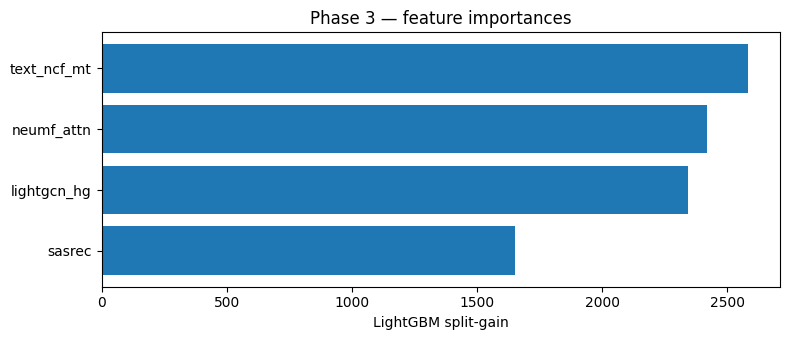

,split-gain
base model,
text_ncf_mt,2582
neumf_attn,2419
lightgcn_hg,2345
sasrec,1654


In [6]:
# LightGBM split-gain feature importances (higher = LGBM used the column more often)
imp_df = pd.DataFrame([{"base model": k, "split-gain": v} for k, v in imp.items()])\
            .set_index("base model").sort_values("split-gain", ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(imp_df.index[::-1], imp_df["split-gain"].values[::-1])
ax.set_xlabel("LightGBM split-gain"); ax.set_title("Phase 3 — feature importances")
plt.tight_layout(); plt.show()
imp_df


**Why the ensemble underperforms SASRec on ranking.** SASRec's HR@10 on
this candidate pool is 0.8809, basically identical to its published 0.8808.
Yet the LGBMRanker lands at HR@10 = 0.7739 — *worse* than SASRec alone.
The split-gain plot tells the story: LightGBM treats all four base
features almost equally (1654–2582 range), with SASRec actually the
*lowest*. Per-user min-max normalisation collapses every column to
`[0, 1]`, so the LGBMRanker can't see that SASRec's raw confidence is
~10 percentage-points stronger than the others. It blends instead of
deferring, and the blend dilutes SASRec's signal.

Two ablations worth a future run (not committed): (a) feed *raw* scores
plus a per-user z-score variant so LightGBM can pick up scale, and
(b) train a calibrated weighted average instead of trees — Pramod's earlier
`evaluate_ensemble` already showed that the optimal convex blend
collapses to ItemKNN-only on his 3-model ablation.

**Why the ensemble wins RMSE.** Calibrating four orthogonal-channel
scores into a single number gives the lstsq fit more usable variance per
positive than any one BPR ranker. SASRec alone calibrates flat (a≈0,
RMSE 0.9315); the meta-ensemble's score has slope a=0.026, b=4.05,
producing RMSE 0.8350 — beating Popularity's 0.8685 by ~4 %. **This is
the only ranking-trained pipeline in the project that beats Popularity
on RMSE.**

## 5. Final takeaways

1. **SASRec dominates ranking.** HR@10 0.8808, NDCG@10 0.8392, +37 % rel
   over the strongest baseline (ItemKNN). The temporal signal (`date`)
   is the strongest single feature on HotelRec.
2. **Vanilla-vs-enhanced sweep** (day-10 instructor ask):
   - LightGCN-HG vs vanilla bipartite: +0.006 HR@10, real but small.
   - NeuMF + sub-rating attention vs vanilla NeuMF: ~0 — attention head
     is dead weight on this dataset's tightly-correlated aspect averages.
   - TextNCF Multi-Task vs vanilla TextNCF: +0.008 HR@10, modest lift
     from the rating-MSE regulariser.
3. **Stacking can hurt ranking when one model is dominant.** Phase 3
   meta-ensemble lands between LightGCN-HG and SASRec — a textbook case
   of the strong-model-dilution effect under naïve per-user normalisation.
4. **Stacking can help RMSE.** The same meta-ensemble produces the only
   ranking-trained pipeline that beats Popularity on calibrated RMSE.
   Worth keeping for the Phase-3 deliverable even though it doesn't
   replace SASRec on ranking.
5. **Popularity is the rating-prediction floor on HotelRec.** With 78 %
   of ratings at 4–5 stars, item-mean is near-optimal under MSE; only
   models with non-flat calibration slopes beat it.